# VE.Direct Dataset Inspection

This notebook is the first implementation of the analysis layer in `acquisition -> storage -> synchronization -> analysis`. It reads one explicitly selected CSV from the synchronized local `data/processed/` directory. It performs no acquisition, synchronization, network, or Raspberry Pi access.

## 1. Configuration

Set `DATA_FILE` to one filename from `data/processed/`. `None` means no dataset is selected; the selection cell will list available CSV files in filename order and stop with an instruction. Paths outside `data/processed/` are rejected.

In [ ]:
DATA_FILE = "vedirect_2026-09-05.csv"

## 2. Imports and dataset resolution

In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def find_repository_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").is_file() and (candidate / "data" / "processed").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


repository_root = find_repository_root(Path.cwd().resolve())
data_root = (repository_root / "data" / "processed").resolve()
available_csv_files = sorted(path.name for path in data_root.glob("*.csv") if path.is_file())

if DATA_FILE is None:
    available = "\n".join(f"  - {name}" for name in available_csv_files) or "  (none found)"
    raise ValueError(
        "No dataset selected. Available processed CSV files:\n"
        f"{available}\n"
        "Set DATA_FILE to one of these filenames and run the notebook again."
    )

configured_path = Path(DATA_FILE)
if configured_path.is_absolute():
    raise ValueError("DATA_FILE must be a filename relative to data/processed/.")

data_path = (data_root / configured_path).resolve()
if data_path.parent != data_root:
    raise ValueError("DATA_FILE must resolve directly within data/processed/.")
if data_path.suffix.lower() != ".csv":
    raise ValueError(f"Selected dataset must be a CSV file: {configured_path}")
if not data_path.is_file():
    raise FileNotFoundError(f"Selected processed CSV does not exist: {data_path}")

print(f"Selected dataset path: {data_path}")

Selected dataset path: /Users/alejandronietocuatenta/Documents/pico/pico_cpp/data/processed/vedirect_2026-09-10.csv


## 3. Load dataset

The required schema is checked explicitly. The timestamp is parsed and preserved as a timezone-aware logger-host local receive/processing timestamp. For Raspberry Pi datasets this is Raspberry Pi local time. It is not converted to UTC, and it is not an MPPT hardware or Pico acquisition timestamp.

In [ ]:
required_columns = [
    "timestamp",
    "sequence",
    "battery_mv",
    "panel_mv",
    "battery_ma",
    "panel_w",
]
numeric_columns = required_columns[1:]

df = pd.read_csv(data_path)
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Processed CSV is missing required columns: {missing_columns}")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="raise")
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")

if df.empty:
    raise ValueError("Processed CSV contains no measurement rows.")
if df["timestamp"].isna().any():
    raise ValueError("Processed CSV contains missing timestamps.")
if df["timestamp"].dt.tz is None:
    raise ValueError("Processed CSV timestamps must include a timezone offset.")
if df[numeric_columns].isna().any().any():
    raise ValueError("Processed CSV contains missing numeric values.")
if not df[numeric_columns].map(math.isfinite).all().all():
    raise ValueError("Processed CSV contains non-finite numeric values.")

In [ ]:
first_timestamp = df["timestamp"].iloc[0]
last_timestamp = df["timestamp"].iloc[-1]
dataset_summary = pd.Series({
    "selected_filename": data_path.name,
    "row_count": len(df),
    "first_timestamp": first_timestamp,
    "last_timestamp": last_timestamp,
    "recording_duration": last_timestamp - first_timestamp,
    "timestamp_timezone": str(df["timestamp"].dt.tz),
    "first_timestamp_offset": first_timestamp.strftime("%z"),
}, name="value")
dataset_summary

selected_filename                  vedirect_2026-09-10.csv
row_count                                            85567
first_timestamp           2026-09-10 00:00:00.129000+02:00
last_timestamp            2026-09-10 23:59:59.670000+02:00
recording_duration                  0 days 23:59:59.541000
timestamp_timezone                               UTC+02:00
first_timestamp_offset                               +0200
Name: value, dtype: object

In [ ]:
df.head()

,timestamp,sequence,battery_mv,panel_mv,battery_ma,panel_w
0,2026-09-10 00:00:00.129000+02:00,365426,12710,10,-30,0
1,2026-09-10 00:00:01.124000+02:00,365427,12710,10,-30,0
2,2026-09-10 00:00:02.119000+02:00,365428,12710,10,-30,0
3,2026-09-10 00:00:03.113000+02:00,365429,12710,10,-30,0
4,2026-09-10 00:00:04.108000+02:00,365430,12710,10,-30,0


In [ ]:
df.tail()

,timestamp,sequence,battery_mv,panel_mv,battery_ma,panel_w
85562,2026-09-10 23:59:55.691000+02:00,450988,13210,10,-150,0
85563,2026-09-10 23:59:56.686000+02:00,450989,13220,10,-180,0
85564,2026-09-10 23:59:57.681000+02:00,450990,13210,10,-190,0
85565,2026-09-10 23:59:58.675000+02:00,450991,13220,10,-200,0
85566,2026-09-10 23:59:59.670000+02:00,450992,13220,10,-170,0


## 4. Dataset integrity summary

Adjacent sequences are classified using their signed difference. Positive jumps greater than one are gaps, zero is a duplicate, and a negative difference is a reset/restart. Reset transitions are classified separately and therefore are not counted as huge numbers of missing samples. UInt32 wraparound is not treated separately in this first notebook.

In [ ]:
sequence_delta = df["sequence"].diff()
transition_type = pd.Series("first", index=df.index, dtype="string")
transition_type.loc[sequence_delta == 1] = "normal"
transition_type.loc[sequence_delta > 1] = "gap"
transition_type.loc[sequence_delta == 0] = "duplicate"
transition_type.loc[sequence_delta < 0] = "reset"

gap_mask = transition_type == "gap"
gap_count = int(gap_mask.sum())
missing_sequence_count = int((sequence_delta.loc[gap_mask] - 1).sum())
duplicate_count = int((transition_type == "duplicate").sum())
reset_count = int((transition_type == "reset").sum())

integrity_summary = pd.Series({
    "sample_count": len(df),
    "first_timestamp": first_timestamp,
    "last_timestamp": last_timestamp,
    "recording_duration": last_timestamp - first_timestamp,
    "first_sequence": int(df["sequence"].iloc[0]),
    "last_sequence": int(df["sequence"].iloc[-1]),
    "sequence_gaps": gap_count,
    "missing_sequences": missing_sequence_count,
    "duplicate_transitions": duplicate_count,
    "reset_transitions": reset_count,
})
integrity_summary

sample_count                                        85567
first_timestamp          2026-09-10 00:00:00.129000+02:00
last_timestamp           2026-09-10 23:59:59.670000+02:00
recording_duration                 0 days 23:59:59.541000
first_sequence                                     365426
last_sequence                                      450992
sequence_gaps                                           0
missing_sequences                                       0
duplicate_transitions                                   0
reset_transitions                                       0
dtype: object

In [ ]:
pd.DataFrame({"missing_values": df[required_columns].isna().sum()})

,missing_values
timestamp,0
sequence,0
battery_mv,0
panel_mv,0
battery_ma,0
panel_w,0


In [ ]:
transition_type.value_counts().rename_axis("transition").to_frame("count")

,count
transition,
normal,85566
first,1


## 5. Timestamp ordering and interval analysis

These are logger-host local receive intervals, not precise MPPT hardware or Pico acquisition intervals. USB transport, serial buffering, host scheduling, and Python execution can introduce unmeasured jitter.

In [ ]:
timestamp_delta = df["timestamp"].diff()
delta_t = timestamp_delta.dt.total_seconds().dropna()

interval_summary = pd.Series({
    "timestamp_order_violations": int((timestamp_delta.dropna() < pd.Timedelta(0)).sum()),
    "duplicate_timestamps": int((timestamp_delta.dropna() == pd.Timedelta(0)).sum()),
    "interval_count": int(delta_t.count()),
    "minimum_s": delta_t.min(),
    "mean_s": delta_t.mean(),
    "median_s": delta_t.median(),
    "maximum_s": delta_t.max(),
    "standard_deviation_s": delta_t.std(),
    "below_0.8_s": int((delta_t < 0.8).sum()),
    "from_0.8_to_1.2_s": int(((delta_t >= 0.8) & (delta_t <= 1.2)).sum()),
    "above_1.2_s": int((delta_t > 1.2).sum()),
})
interval_summary

timestamp_order_violations        0.000000
duplicate_timestamps              0.000000
interval_count                85566.000000
minimum_s                         0.994000
mean_s                            1.009741
median_s                          0.995000
maximum_s                        36.796000
standard_deviation_s              0.184399
below_0.8_s                       0.000000
from_0.8_to_1.2_s             84772.000000
above_1.2_s                     794.000000
dtype: float64

## 6. Engineering-unit conversion

Original acquisition columns remain unchanged. The presentation columns convert mV to V and mA to A. Positive `battery_a` means charging; negative `battery_a` means discharging.

In [ ]:
df["battery_v"] = df["battery_mv"] / 1000.0
df["panel_v"] = df["panel_mv"] / 1000.0
df["battery_a"] = df["battery_ma"] / 1000.0

df[["timestamp", "sequence", "battery_v", "panel_v", "battery_a", "panel_w"]].head()

,timestamp,sequence,battery_v,panel_v,battery_a,panel_w
0,2026-09-10 00:00:00.129000+02:00,365426,12.71,0.01,-0.03,0
1,2026-09-10 00:00:01.124000+02:00,365427,12.71,0.01,-0.03,0
2,2026-09-10 00:00:02.119000+02:00,365428,12.71,0.01,-0.03,0
3,2026-09-10 00:00:03.113000+02:00,365429,12.71,0.01,-0.03,0
4,2026-09-10 00:00:04.108000+02:00,365430,12.71,0.01,-0.03,0


## 7. Descriptive statistics

In [ ]:
analysis_columns = {
    "Battery voltage [V]": "battery_v",
    "PV voltage [V]": "panel_v",
    "Battery current [A]": "battery_a",
    "PV power [W]": "panel_w",
}

descriptive_statistics = pd.DataFrame({
    label: {
        "minimum": df[column].min(),
        "mean": df[column].mean(),
        "median": df[column].median(),
        "maximum": df[column].max(),
        "standard_deviation": df[column].std(),
    }
    for label, column in analysis_columns.items()
}).T
descriptive_statistics

,minimum,mean,median,maximum,standard_deviation
Battery voltage [V],12.14,13.046702,13.23,14.38,0.429186
PV voltage [V],0.01,7.271791,0.01,24.72,9.932067
Battery current [A],-3.24,0.172108,-0.03,2.07,0.495801
PV power [W],0.00,3.550294,0.00,30.00,6.599834


## 8. Basic time-series plots

Each figure uses timezone-aware logger-host local receive time on the x-axis and keeps matplotlib's default styling.

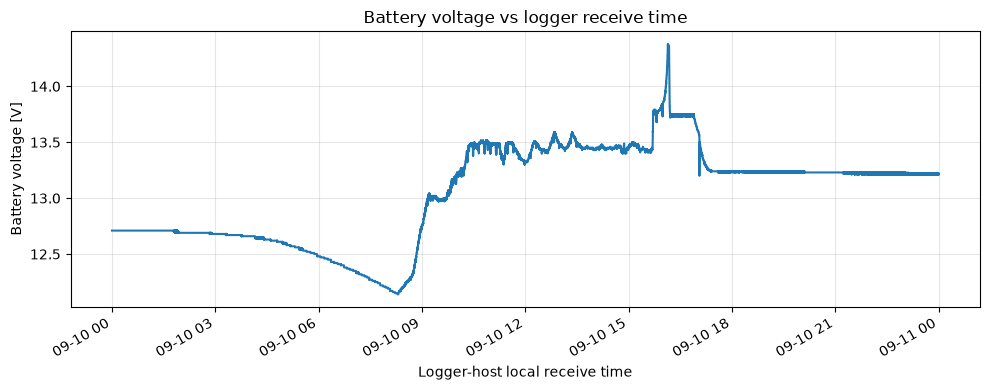

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["battery_v"])
plt.title("Battery voltage vs logger receive time")
plt.xlabel("Logger-host local receive time")
plt.ylabel("Battery voltage [V]")
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

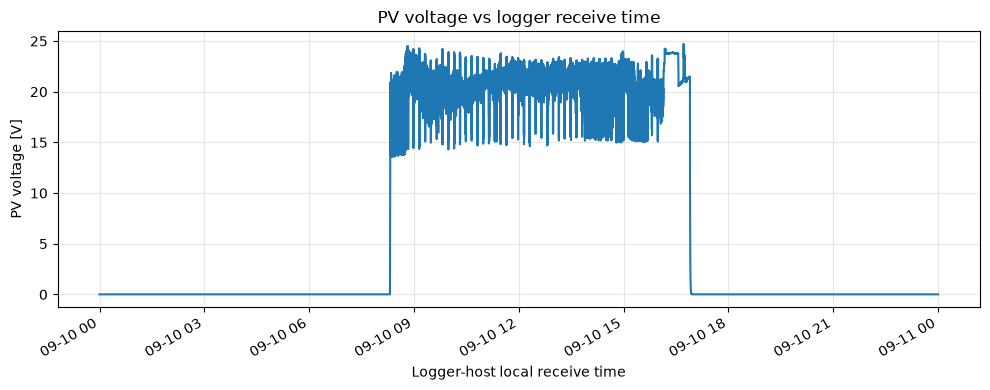

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["panel_v"])
plt.title("PV voltage vs logger receive time")
plt.xlabel("Logger-host local receive time")
plt.ylabel("PV voltage [V]")
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

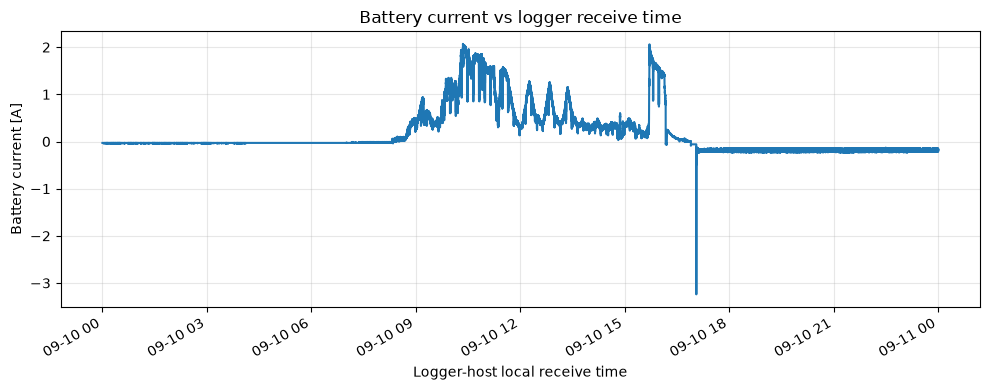

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["battery_a"])
plt.title("Battery current vs logger receive time")
plt.xlabel("Logger-host local receive time")
plt.ylabel("Battery current [A]")
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

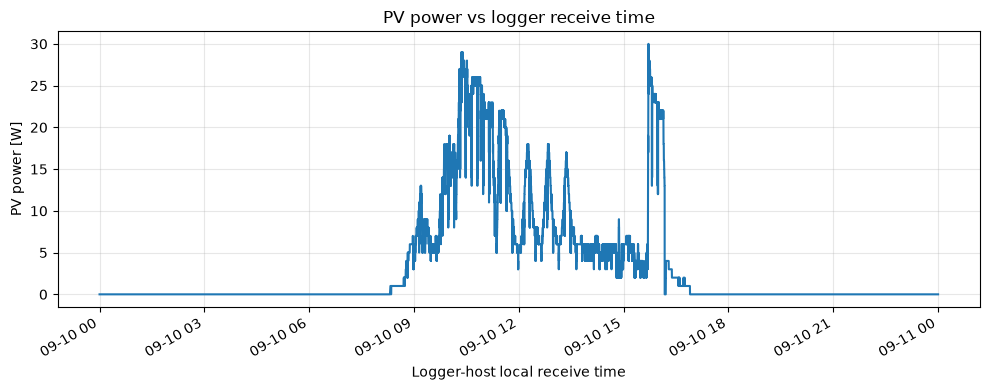

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["panel_w"])
plt.title("PV power vs logger receive time")
plt.xlabel("Logger-host local receive time")
plt.ylabel("PV power [W]")
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Analytical limits

This dataset does **not** directly measure solar irradiance, ambient temperature, panel temperature, or accurate battery state of charge. None of those quantities should be presented as directly measured. This first notebook intentionally excludes multi-file/date-range analysis, energy or Wh calculations, charger-state analysis, new VE.Direct fields, and dashboard work.

## 10. Session summary

In [ ]:
session_summary = pd.DataFrame([{
    "file_name": data_path.name,
    "sample_count": len(df),
    "duration": last_timestamp - first_timestamp,
    "first_sequence": int(df["sequence"].iloc[0]),
    "last_sequence": int(df["sequence"].iloc[-1]),
    "sequence_gaps": gap_count,
    "missing_sequence_count": missing_sequence_count,
    "duplicate_count": duplicate_count,
    "reset_count": reset_count,
    "mean_receive_interval_s": delta_t.mean(),
    "battery_voltage_min_v": df["battery_v"].min(),
    "battery_voltage_max_v": df["battery_v"].max(),
    "pv_voltage_min_v": df["panel_v"].min(),
    "pv_voltage_max_v": df["panel_v"].max(),
    "battery_current_min_a": df["battery_a"].min(),
    "battery_current_max_a": df["battery_a"].max(),
    "pv_power_min_w": df["panel_w"].min(),
    "pv_power_max_w": df["panel_w"].max(),
}])
session_summary.T.rename(columns={0: "value"})

,value
file_name,vedirect_2026-09-10.csv
sample_count,85567
duration,0 days 23:59:59.541000
first_sequence,365426
last_sequence,450992
sequence_gaps,0
missing_sequence_count,0
duplicate_count,0
reset_count,0
mean_receive_interval_s,1.009741
